##Loading the  graphs

In [7]:
# Inspect the first few lines of soc-advogato.edges to determine its delimiter
!head -n 5 soc-advogato.edges

% asym posweighted
% 51332 6551 6551
% ent.developer ent.developer weight.certificate
1 1 .8
1 2 1


In [8]:
!head -n 5 soc-sign-bitcoinalpha.edges

7188,1,10,1407470400
430,1,10,1376539200
3134,1,10,1369713600
3026,1,10,1350014400
3010,1,10,1347854400


In [9]:
!head -n 5 soc-sign-bitcoinotc.edges

6,2,4,1289241911.72836
6,5,2,1289241941.53378
1,15,1,1289243140.39049
4,3,7,1289245277.36975
13,16,8,1289254254.44746


In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from scipy.io import mmread
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict
import tracemalloc
real_world_graphs = {}

# Process .edges files
edge_files = ['soc-sign-bitcoinalpha.edges', 'soc-sign-bitcoinotc.edges', 'soc-advogato.edges']
for i in edge_files:
    print(f"\n--- Processing {i} ---")
    try:
        if i == 'soc-advogato.edges':
            G = nx.read_edgelist(
                i,
                delimiter=' ',
                comments='%',
                create_using=nx.Graph(),
                data=[('weight', float)] # Only weight for advogato
            )
        else:
            G = nx.read_edgelist(
                i,
                delimiter=',',
                create_using=nx.Graph(),
                data=[('weight', float), ('time', float)] # Weight and time for these files
            )
        real_world_graphs[i.split('.')[0].replace('-', '_')] = G
        print(f"Number of nodes in {i}: {G.number_of_nodes()}")
        print(f"Number of edges in {i}: {G.number_of_edges()}")
    except FileNotFoundError:
        print(f"Warning: {i} not found in the current directory.")

# Process .mtx files
for j in ['soc-epinions.mtx','soc-LiveMocha.mtx']:
    try:
        R = mmread(j)
        G = nx.from_scipy_sparse_array(R)
        real_world_graphs[j.split('.')[0].replace('-', '_')] = G
        print(f"\n--- Processed {j} ---")
        print(f"Number of nodes in {j}: {G.number_of_nodes()}")
        print(f"Number of edges in {j}: {G.number_of_edges()}")
    except FileNotFoundError:
        print(f"Warning: {j} not found in the current directory.")

print(f"\nAvailable real-world graphs: {list(real_world_graphs.keys())}")



def convert_nx_to_dijkstra(nx_graph):
    """
    Extracts nodes and edges from a NetworkX graph and populates
    the custom BidirectionalDijkstra object.
    """
    graph_obj = BidirectionalDijkstra()

    # NetworkX nodes can be strings or ints depending on the file parser.
    # We extract them as a list to allow random sampling.
    nodes = list(nx_graph.nodes())

    for u, v, data in nx_graph.edges(data=True):
        # Default to weight 1.0 if the graph happens to be unweighted
        weight = data.get('weight', 1.0)

        # The add_edge method naturally makes it undirected, satisfying project requirements
        graph_obj.add_edge(u, v, weight)

    return graph_obj, nodes


--- Processing soc-sign-bitcoinalpha.edges ---
Number of nodes in soc-sign-bitcoinalpha.edges: 3783
Number of edges in soc-sign-bitcoinalpha.edges: 14124

--- Processing soc-sign-bitcoinotc.edges ---
Number of nodes in soc-sign-bitcoinotc.edges: 5881
Number of edges in soc-sign-bitcoinotc.edges: 21492

--- Processing soc-advogato.edges ---
Number of nodes in soc-advogato.edges: 6551
Number of edges in soc-advogato.edges: 43427

--- Processed soc-epinions.mtx ---
Number of nodes in soc-epinions.mtx: 26588
Number of edges in soc-epinions.mtx: 100120

--- Processed soc-LiveMocha.mtx ---
Number of nodes in soc-LiveMocha.mtx: 104103
Number of edges in soc-LiveMocha.mtx: 2193083

Available real-world graphs: ['soc_sign_bitcoinalpha', 'soc_sign_bitcoinotc', 'soc_advogato', 'soc_epinions', 'soc_LiveMocha']


##Bidirectional Dijkstra

In [10]:
class BidirectionalDijkstra:
    def __init__(self):
        # Using a defaultdict to represent the adjacency list
        self.graph = defaultdict(list)

    def add_edge(self, u, v, weight):

        self.graph[u].append((v, weight))
        self.graph[v].append((u, weight))

    def compute_shortest_path(self, source, target):

        start_time = time.perf_counter()

        if source == target:
            return 0, [source], 0.0

        pq_forward = [(0, source)]
        pq_backward = [(0, target)]


        dist_forward = {source: 0}
        dist_backward = {target: 0}

        parent_forward = {source: None}
        parent_backward = {target: None}

        visited_forward = set()
        visited_backward = set()

        best_distance = float('inf')
        meeting_node = None

        while pq_forward and pq_backward:
            # Termination Condition:
            # If the sum of the minimum distances in both priority queues exceeds or
            # equals the best distance found, we have guaranteed the optimal path.
            if pq_forward[0][0] + pq_backward[0][0] >= best_distance:
                break

            # Always expand the search frontier that has fewer elements
            if len(pq_forward) <= len(pq_backward):
                best_distance, meeting_node = self._expand_frontier(
                    pq_forward, dist_forward, parent_forward, visited_forward,
                    dist_backward, best_distance, meeting_node
                )
            else:
                best_distance, meeting_node = self._expand_frontier(
                    pq_backward, dist_backward, parent_backward, visited_backward,
                    dist_forward, best_distance, meeting_node
                )

        if best_distance == float('inf'):
            return float('inf'), [], time.perf_counter() - start_time

        # Reconstruct the final path
        path = self._reconstruct_path(parent_forward, parent_backward, meeting_node)
        exec_time = time.perf_counter() - start_time

        return best_distance, path, exec_time

    def _expand_frontier(self, pq, dist_current, parent_current, visited_current,
                         dist_opposite, best_distance, meeting_node):

        current_dist, u = heapq.heappop(pq)

        if u in visited_current:
            return best_distance, meeting_node

        visited_current.add(u)

        for v, weight in self.graph[u]:
            if v in visited_current:
                continue

            new_dist = current_dist + weight

            if new_dist < dist_current.get(v, float('inf')):
                dist_current[v] = new_dist
                parent_current[v] = u
                heapq.heappush(pq, (new_dist, v))

                # Check if this node has already been reached by the opposing search
                if v in dist_opposite:
                    path_len = new_dist + dist_opposite[v]
                    if path_len < best_distance:
                        best_distance = path_len
                        meeting_node = v

        return best_distance, meeting_node

    def _reconstruct_path(self, parent_forward, parent_backward, meeting_node):

        path = []

        # Traverse backward from the meeting node to the source
        curr = meeting_node
        while curr is not None:
            path.append(curr)
            curr = parent_forward.get(curr)
        path.reverse() # Reverse to get Source -> Meeting Node

        # Traverse forward from the meeting node to the target
        curr = parent_backward.get(meeting_node)
        while curr is not None:
            path.append(curr)
            curr = parent_backward.get(curr)

        return path

###Implementing on Datasets

In [11]:
scalability_benchmark_results = {
    "dataset": [],
    "nodes": [],
    "edges": [],
    "avg_exec_time_sec": [],
    "avg_peak_memory_mb": []
}

NUM_TRIALS = 50

print("\n--- Starting Bidirectional Dijkstra Scalability Benchmarks ---")

for name, nx_graph in real_world_graphs.items():
    print(f"Preparing {name}...")

    graph, node_list = convert_nx_to_dijkstra(nx_graph)

    total_time = 0.0
    total_memory_mb = 0.0
    valid_trials = 0

    print(f"Benchmarking {name} for {NUM_TRIALS} queries...")
    for _ in range(NUM_TRIALS):
        source = random.choice(node_list)
        target = random.choice(node_list)

        tracemalloc.start()

        distance, path, exec_time = graph.compute_shortest_path(source, target)

        current_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        if distance != float('inf'):
            total_time += exec_time
            # Convert peak memory from bytes to Megabytes
            total_memory_mb += peak_mem / (1024 * 1024)
            valid_trials += 1

    avg_time = total_time / valid_trials if valid_trials > 0 else 0
    avg_mem = total_memory_mb / valid_trials if valid_trials > 0 else 0

    scalability_benchmark_results["dataset"].append(name)
    scalability_benchmark_results["nodes"].append(nx_graph.number_of_nodes())
    scalability_benchmark_results["edges"].append(nx_graph.number_of_edges())
    scalability_benchmark_results["avg_exec_time_sec"].append(avg_time)
    scalability_benchmark_results["avg_peak_memory_mb"].append(avg_mem)

    print(f"Completed {name}: Avg Time = {avg_time:.6f}s, Peak Mem = {avg_mem:.4f} MB\n")

# Display the final scalability benchmark results
scalability_results_df = pd.DataFrame(scalability_benchmark_results)
display(scalability_results_df)


--- Starting Bidirectional Dijkstra Scalability Benchmarks ---
Preparing soc_sign_bitcoinalpha...
Benchmarking soc_sign_bitcoinalpha for 50 queries...
Completed soc_sign_bitcoinalpha: Avg Time = 0.002492s, Peak Mem = 0.0591 MB

Preparing soc_sign_bitcoinotc...
Benchmarking soc_sign_bitcoinotc for 50 queries...
Completed soc_sign_bitcoinotc: Avg Time = 0.002845s, Peak Mem = 0.0650 MB

Preparing soc_advogato...
Benchmarking soc_advogato for 50 queries...
Completed soc_advogato: Avg Time = 0.005250s, Peak Mem = 0.1109 MB

Preparing soc_epinions...
Benchmarking soc_epinions for 50 queries...
Completed soc_epinions: Avg Time = 0.005060s, Peak Mem = 0.1406 MB

Preparing soc_LiveMocha...
Benchmarking soc_LiveMocha for 50 queries...
Completed soc_LiveMocha: Avg Time = 0.058238s, Peak Mem = 1.4525 MB



,dataset,nodes,edges,avg_exec_time_sec,avg_peak_memory_mb
0,soc_sign_bitcoinalpha,3783,14124,0.002492,0.059124
1,soc_sign_bitcoinotc,5881,21492,0.002845,0.064969
2,soc_advogato,6551,43427,0.005250,0.110855
3,soc_epinions,26588,100120,0.005060,0.140587
4,soc_LiveMocha,104103,2193083,0.058238,1.452538


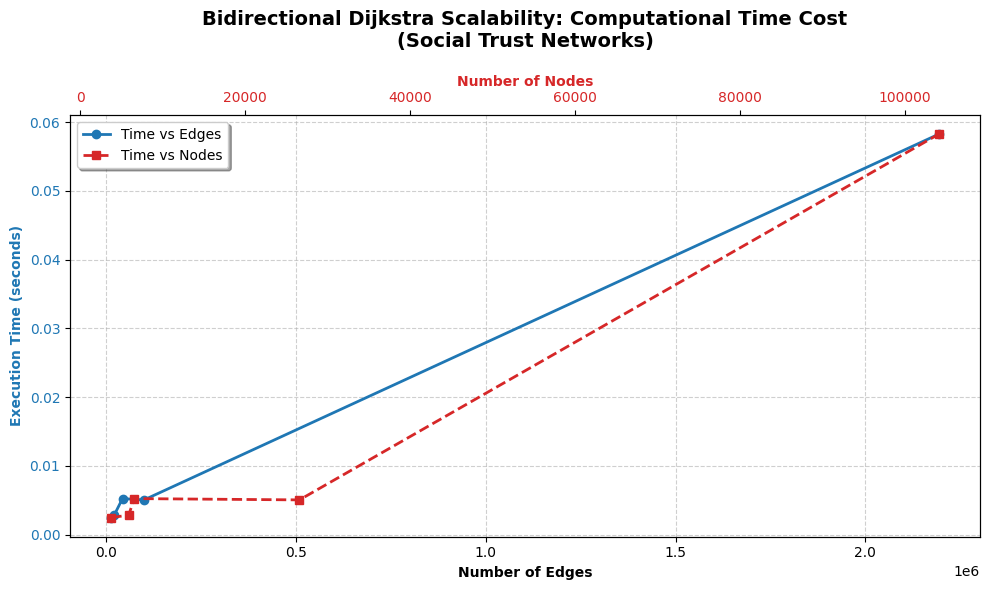

In [12]:
df_sorted = scalability_results_df.sort_values(by="edges")

fig, ax1 = plt.subplots(figsize=(10, 6))

# Execution Time Scalability
color1 = 'tab:blue'
ax1.set_xlabel('Number of Edges', fontweight='bold')
ax1.set_ylabel('Execution Time (seconds)', color=color1, fontweight='bold')
line1, = ax1.plot(df_sorted["edges"], df_sorted["avg_exec_time_sec"],
                  color=color1, marker='o', linewidth=2, label="Time vs Edges")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Secondary X-axis for Nodes
ax2 = ax1.twiny()
color2 = 'tab:red'
ax2.set_xlabel('Number of Nodes', color=color2, fontweight='bold')
line2, = ax2.plot(df_sorted["nodes"], df_sorted["avg_exec_time_sec"],
                  color=color2, marker='s', linewidth=2, linestyle='--', label="Time vs Nodes")
ax2.tick_params(axis='x', labelcolor=color2)

plt.title('Bidirectional Dijkstra Scalability: Computational Time Cost\n(Social Trust Networks)',
          pad=20, fontweight='bold', fontsize=14)

# Combine legends
lines_time = [line1, line2]
labels_time = [l.get_label() for l in lines_time]
ax1.legend(lines_time, labels_time, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('bidi_time_scalability_curve.png', dpi=300)
plt.show()

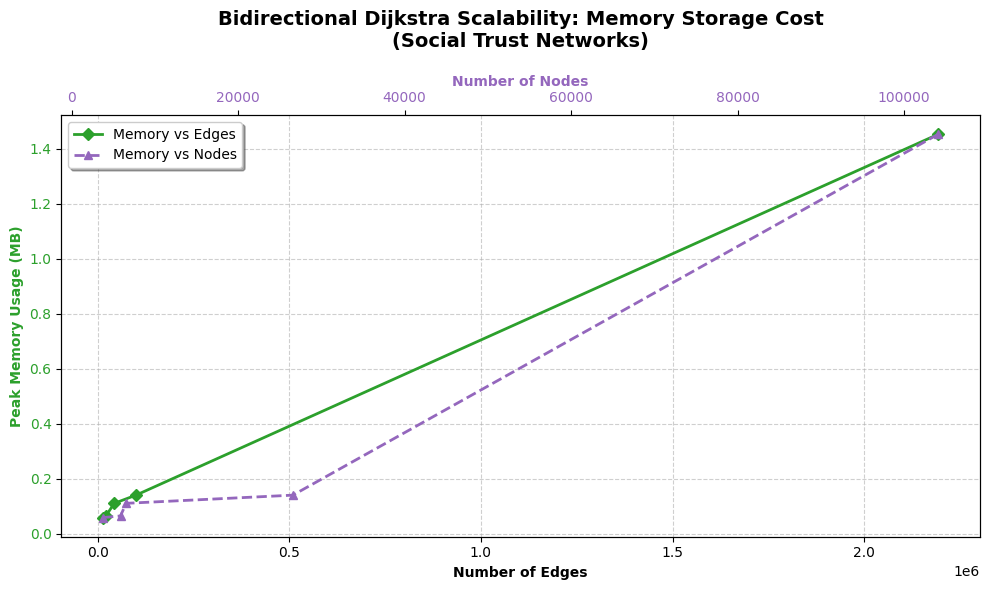

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Memory Usage Scalability
color3 = 'tab:green'
ax1.set_xlabel('Number of Edges', fontweight='bold')
ax1.set_ylabel('Peak Memory Usage (MB)', color=color3, fontweight='bold')
line3, = ax1.plot(df_sorted["edges"], df_sorted["avg_peak_memory_mb"],
                  color=color3, marker='D', linewidth=2, label="Memory vs Edges")
ax1.tick_params(axis='y', labelcolor=color3)
ax1.grid(True, linestyle='--', alpha=0.6)

# Secondary X-axis for Nodes
ax2 = ax1.twiny()
color4 = 'tab:purple'
ax2.set_xlabel('Number of Nodes', color=color4, fontweight='bold')
line4, = ax2.plot(df_sorted["nodes"], df_sorted["avg_peak_memory_mb"],
                  color=color4, marker='^', linewidth=2, linestyle='--', label="Memory vs Nodes")
ax2.tick_params(axis='x', labelcolor=color4)

plt.title('Bidirectional Dijkstra Scalability: Memory Storage Cost\n(Social Trust Networks)',
          pad=20, fontweight='bold', fontsize=14)

# Combine legends
lines_mem = [line3, line4]
labels_mem = [l.get_label() for l in lines_mem]
ax1.legend(lines_mem, labels_mem, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('bidi_memory_scalability_curve.png', dpi=300)
plt.show()

##Distance Oracles

In [ ]:
import random
import time
import networkx as nx

class LandmarkDistanceOracle:
    def __init__(self, graph, num_landmarks=10):
        self.graph = graph
        self.num_landmarks = num_landmarks
        self.landmarks = []
        self.distances = {}

    def preprocess(self):
        nodes = list(self.graph.nodes())

        self.landmarks = random.sample(
            nodes,
            min(self.num_landmarks, len(nodes))
        )

        for landmark in self.landmarks:
            self.distances[landmark] = nx.single_source_dijkstra_path_length(
                self.graph,
                landmark,
                weight="weight"
            )

    def query(self, source, target):
        if source == target:
            return 0, None

        best_distance = float("inf")
        best_landmark = None

        for landmark in self.landmarks:
            dist = self.distances[landmark]

            if source in dist and target in dist:
                estimated_distance = dist[source] + dist[target]

                if estimated_distance < best_distance:
                    best_distance = estimated_distance
                    best_landmark = landmark

        return best_distance, best_landmark

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from scipy.io import mmread
import pandas as pd
import random
import time

# --- YOUR DATA LOADING CODE ---
real_world_graphs = {}

# Process .edges files
edge_files = ['soc-sign-bitcoinalpha.edges', 'soc-sign-bitcoinotc.edges', 'soc-advogato.edges']
for i in edge_files:
    print(f"\n--- Processing {i} ---")
    try:
        if i == 'soc-advogato.edges':
            G = nx.read_edgelist(
                i,
                delimiter=' ',        # Space-separated for advogato
                comments='%',         # Comments start with '%' for advogato
                create_using=nx.DiGraph(),
                data=[('weight', float)] # Only weight for advogato
            )
        else:
            G = nx.read_edgelist(
                i,
                delimiter=',',        # Comma-separated for these files
                create_using=nx.DiGraph(),
                data=[('weight', float), ('time', float)] # Weight and time for these files
            )
        real_world_graphs[i.split('.')[0].replace('-', '_')] = G
        print(f"Number of nodes in {i}: {G.number_of_nodes()}")
        print(f"Number of edges in {i}: {G.number_of_edges()}")
    except FileNotFoundError:
        print(f"Warning: {i} not found in the current directory.")

# Process .mtx files
for j in ['soc-epinions.mtx','soc-LiveMocha.mtx']:
    try:
        R = mmread(j)
        G = nx.from_scipy_sparse_array(R)
        real_world_graphs[j.split('.')[0].replace('-', '_')] = G
        print(f"\n--- Processed {j} ---")
        print(f"Number of nodes in {j}: {G.number_of_nodes()}")
        print(f"Number of edges in {j}: {G.number_of_edges()}")
    except FileNotFoundError:
        print(f"Warning: {j} not found in the current directory.")

print(f"\nAvailable real-world graphs: {list(real_world_graphs.keys())}")


--- Processing soc-sign-bitcoinalpha.edges ---
Number of nodes in soc-sign-bitcoinalpha.edges: 3783
Number of edges in soc-sign-bitcoinalpha.edges: 24186

--- Processing soc-sign-bitcoinotc.edges ---
Number of nodes in soc-sign-bitcoinotc.edges: 5881
Number of edges in soc-sign-bitcoinotc.edges: 35592

--- Processing soc-advogato.edges ---
Number of nodes in soc-advogato.edges: 6551
Number of edges in soc-advogato.edges: 51317

--- Processed soc-epinions.mtx ---
Number of nodes in soc-epinions.mtx: 26588
Number of edges in soc-epinions.mtx: 100120

--- Processed soc-LiveMocha.mtx ---
Number of nodes in soc-LiveMocha.mtx: 104103
Number of edges in soc-LiveMocha.mtx: 2193083

Available real-world graphs: ['soc_sign_bitcoinalpha', 'soc_sign_bitcoinotc', 'soc_advogato', 'soc_epinions', 'soc_LiveMocha']


In [ ]:
print(real_world_graphs.keys())

dict_keys([])


In [ ]:
graphs = {
    "soc-sign-bitcoinalpha": real_world_graphs["soc_sign_bitcoinalpha"],
    "soc-sign-bitcoinotc": real_world_graphs["soc_sign_bitcoinotc"],
    "soc-advogato": real_world_graphs["soc_advogato"],
    "soc-epinions": real_world_graphs["soc_epinions"],
    "soc-LiveMocha": real_world_graphs["soc_LiveMocha"]
}

for name, graph in graphs.items():
    print("\n==============================")
    print(name)
    print("==============================")

    nodes = list(graph.nodes())

    if len(nodes) < 2:
        print("Graph too small.")
        continue

    # Ensure all edge weights are non-negative for Dijkstra-based algorithms
    # Iterates over all edges in the current graph. 'data=True' ensures that
    # edge attributes, including 'weight', are returned.
    for u, v, data in graph.edges(data=True):
        if 'weight' in data and data['weight'] < 0:
            # If a negative weight is found, it's replaced with its absolute value.
            # This makes the weight non-negative, allowing Dijkstra's algorithm to function correctly.
            data['weight'] = abs(data['weight'])

    source = nodes[0]
    target = nodes[-1]

    oracle = LandmarkDistanceOracle(graph, num_landmarks=10)

    start_time = time.time()
    oracle.preprocess()
    preprocessing_time = time.time() - start_time

    start_time = time.time()
    estimated_distance, landmark = oracle.query(source, target)
    query_time = time.time() - start_time

    print("Number of nodes:", graph.number_of_nodes())
    print("Number of edges:", graph.number_of_edges())
    print("Source:", source)
    print("Target:", target)
    print("Number of landmarks:", len(oracle.landmarks))
    print("Best landmark used:", landmark)
    print("Estimated distance:", estimated_distance)
    print("Preprocessing time:", preprocessing_time)
    print("Query time:", query_time)


soc-sign-bitcoinalpha
Number of nodes: 3783
Number of edges: 24186
Source: 7188
Target: 7466
Number of landmarks: 10
Best landmark used: None
Estimated distance: inf
Preprocessing time: 0.16449713706970215
Query time: 1.7881393432617188e-05

soc-sign-bitcoinotc
Number of nodes: 5881
Number of edges: 35592
Source: 6
Target: 6005
Number of landmarks: 10
Best landmark used: 251
Estimated distance: 4.0
Preprocessing time: 0.333416223526001
Query time: 2.0265579223632812e-05

soc-advogato
Number of nodes: 6551
Number of edges: 51317
Source: 1
Target: 6551
Number of landmarks: 10
Best landmark used: None
Estimated distance: inf
Preprocessing time: 0.2855801582336426
Query time: 1.6450881958007812e-05

soc-epinions
Number of nodes: 26588
Number of edges: 100120
Source: 0
Target: 26587
Number of landmarks: 10
Best landmark used: 126
Estimated distance: 6.0
Preprocessing time: 2.54093074798584
Query time: 2.2411346435546875e-05

soc-LiveMocha
Number of nodes: 104103
Number of edges: 2193083
So

In [ ]:
import time
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt
import random

oracle_results = []

for name, graph in graphs.items():
    nodes = list(graph.nodes())

    if len(nodes) < 2:
        continue

    source = random.choice(nodes)
    target = random.choice(nodes)

    oracle = LandmarkDistanceOracle(graph, num_landmarks=10)

    tracemalloc.start()

    start_time = time.time()
    oracle.preprocess()
    preprocessing_time = time.time() - start_time

    current_memory, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    start_time = time.time()
    estimated_distance, landmark = oracle.query(source, target)
    query_time = time.time() - start_time

    oracle_results.append({
        "Dataset": name,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Preprocessing Time": preprocessing_time,
        "Query Time": query_time,
        "Peak Memory MB": peak_memory / 1024 / 1024,
        "Estimated Distance": estimated_distance
    })

oracle_df = pd.DataFrame(oracle_results)
oracle_df

,Dataset,Nodes,Edges,Preprocessing Time,Query Time,Peak Memory MB,Estimated Distance
0,soc-sign-bitcoinalpha,3783,24186,1.112550,0.000042,1.868950,9.0
1,soc-sign-bitcoinotc,5881,35592,1.290506,0.000040,3.622932,8.0
2,soc-advogato,6551,51317,0.646297,0.000031,1.588669,4.2
3,soc-epinions,26588,100120,6.219751,0.000036,21.061443,7.0
4,soc-LiveMocha,104103,2193083,97.581314,0.000056,84.800129,5.0


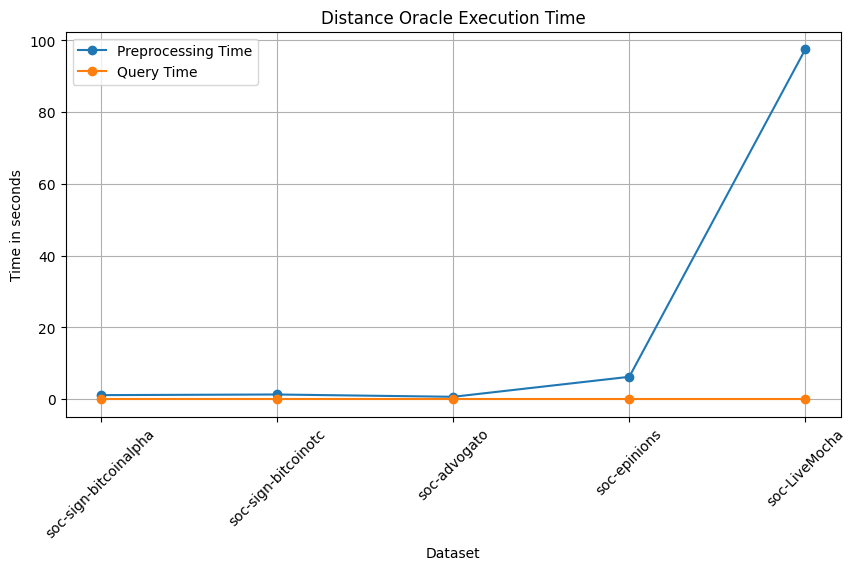

In [ ]:
#Execution time graph

plt.figure(figsize=(10, 5))
plt.plot(oracle_df["Dataset"], oracle_df["Preprocessing Time"], marker="o", label="Preprocessing Time")
plt.plot(oracle_df["Dataset"], oracle_df["Query Time"], marker="o", label="Query Time")

plt.xlabel("Dataset")
plt.ylabel("Time in seconds")
plt.title("Distance Oracle Execution Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

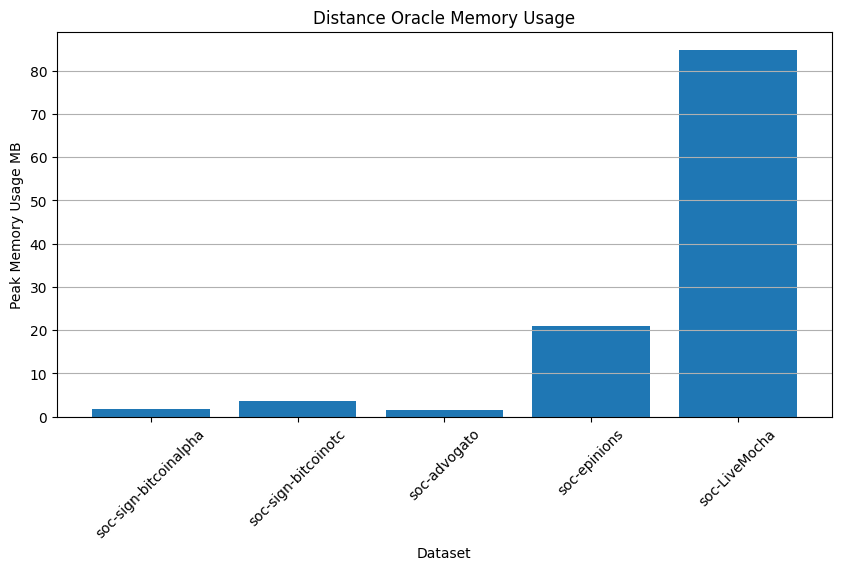

In [ ]:
#Memory usage graph

plt.figure(figsize=(10, 5))
plt.bar(oracle_df["Dataset"], oracle_df["Peak Memory MB"])

plt.xlabel("Dataset")
plt.ylabel("Peak Memory Usage MB")
plt.title("Distance Oracle Memory Usage")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

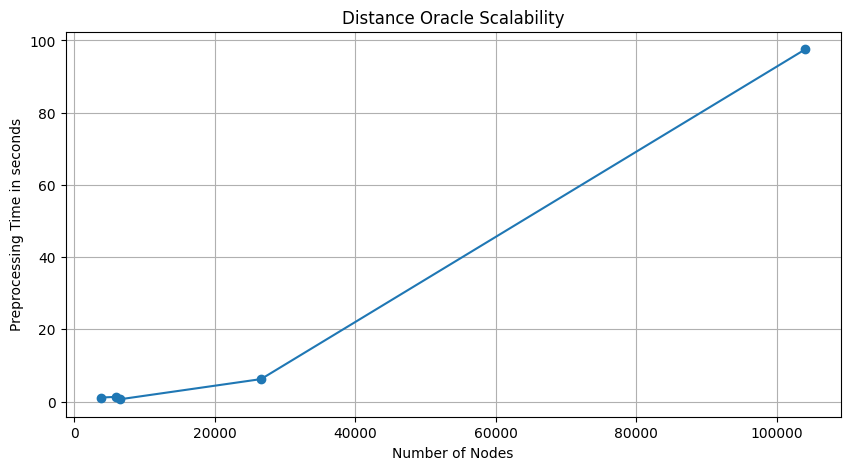

In [ ]:
#Scalability graph

plt.figure(figsize=(10, 5))
plt.plot(oracle_df["Nodes"], oracle_df["Preprocessing Time"], marker="o")

plt.xlabel("Number of Nodes")
plt.ylabel("Preprocessing Time in seconds")
plt.title("Distance Oracle Scalability")
plt.grid(True)
plt.show()